___
# RASTERIO

In [9]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import ticker

from matplotlib.patches import Rectangle

In [10]:
# Helper function to plot the base map and all boxes
def plot_region(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='grey', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Step 1: Load your data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'
start_file = 'IDLloc_spawning_21dfilter.csv'
starting_location_df = pd.read_csv(output_path + start_file)

In [12]:
fig_path = repo_path + 'figures/'

## Use Perry et al resolution: 1 ̊latitude by 2 ̊ longitude grid cells

In [43]:
# Set the color scale limits
vmin = 0  # Minimum value for colorbar
vmax = 45  # Maximum value for colorbar

In [44]:
# Pre-process and filter the dataframe
def preprocess_data(df, start_years, hypothesis, nursery_loc):
    subset_df = df[(df['hypothesis'] == hypothesis) & (df['IDL_loc'] == nursery_loc)]
    df_filtered = subset_df[subset_df['start_year'].isin(start_years)].copy()
    return df_filtered

# Define your parameters
start_years = [2016]
hyp = 'h_ice'
nursery = 'BS'

# Pre-process the data
df_filtered = preprocess_data(starting_location_df, start_years, hyp, nursery)

# Step 2: Fix longitudes in the range [0, 360] to [-180, 180]
df_filtered['release_lon'] = df_filtered['release_lon'].apply(lambda lon: lon - 360 if lon > 180 else lon)


In [45]:
# Step 3: Define the coarse grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = 1  # 1 degree latitude resolution
lon_resolution = 2  # 2 degree longitude resolution

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 4: Create a 2D array to hold the counts for each grid cell
coarse_heatmap = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Step 5: Bin the data points into the new coarse grid
for _, row in df_filtered.iterrows():
    lat_idx = np.digitize(row['release_lat'], lat_bins) - 1
    lon_idx = np.digitize(row['release_lon'], lon_bins) - 1

    # Ensure the point falls within the grid bounds
    if 0 <= lat_idx < len(lat_bins) - 1 and 0 <= lon_idx < len(lon_bins) - 1:
        coarse_heatmap[lat_idx, lon_idx] += 1  # Increment the count for the grid cell

# Step 6: Convert the coarse heatmap into an xarray DataArray for easy plotting
coarse_heatmap_xr = xr.DataArray(
    coarse_heatmap,
    coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
            ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
    dims=['latitude', 'longitude']
)

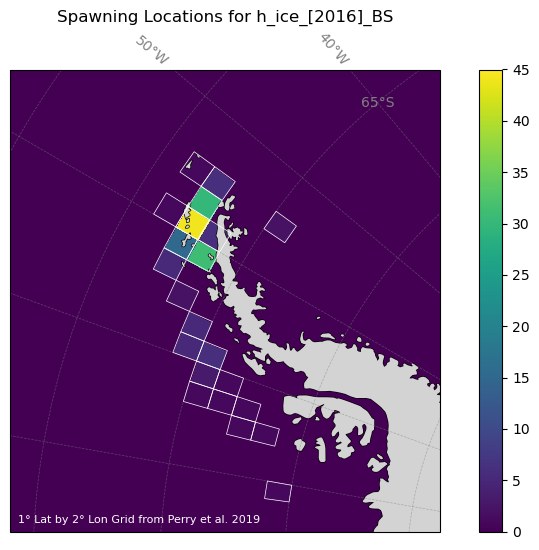

In [46]:
# Step 7: Plot the coarse grid heatmap over the base map
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [-85, -49, -72, -59]  # Adjust extent to -180 to 180 longitude format

# Plot the base map with the region
plot_region(ax, extent)

# Overlay the heatmap using pcolormesh for proper alignment with lat/lon
heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap='viridis',
                                                 transform=ccrs.PlateCarree(),
                                                 vmin=vmin, vmax=vmax,
                                                 add_colorbar=True)

# Outline grid cells where the values are greater than zero
for lat_idx in range(len(lat_bins) - 1):
    for lon_idx in range(len(lon_bins) - 1):
        if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
            # Get the corners of the grid cell
            lon_start = lon_bins[lon_idx]
            lon_end = lon_bins[lon_idx + 1]
            lat_start = lat_bins[lat_idx]
            lat_end = lat_bins[lat_idx + 1]
            
            # Create a rectangle patch for the grid cell
            rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                             linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                             transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
            ax.add_patch(rect)

# Add annotation text
ax.text(0.3, 0.025,  # Coordinates in figure space (x, y)
    "1° Lat by 2° Lon Grid from Perry et al. 2019", 
    transform=ax.transAxes,  # Use axis coordinates for positioning
    ha='center', va='center', fontsize=8, color='white')

plt.title(f'Spawning Locations for {hyp}_{start_years}_{nursery}')
# Save the plot before showing it
plt.savefig(f"{fig_path}/PERRYGRID_spawning_locations_{hyp}_{start_years}_{nursery}.png", dpi=300, bbox_inches='tight')  # Save as a PNG image with 300 DPI

plt.show()

REPEAT!

In [47]:
# Define your parameters
start_years = [2017]
hyp = 'h_ice'
nursery = 'BS'

# Pre-process the data
df_filtered = preprocess_data(starting_location_df, start_years, hyp, nursery)

# Step 2: Fix longitudes in the range [0, 360] to [-180, 180]
df_filtered['release_lon'] = df_filtered['release_lon'].apply(lambda lon: lon - 360 if lon > 180 else lon)


In [48]:
# Step 3: Define the coarse grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = 1  # 1 degree latitude resolution
lon_resolution = 2  # 2 degree longitude resolution

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 4: Create a 2D array to hold the counts for each grid cell
coarse_heatmap = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Step 5: Bin the data points into the new coarse grid
for _, row in df_filtered.iterrows():
    lat_idx = np.digitize(row['release_lat'], lat_bins) - 1
    lon_idx = np.digitize(row['release_lon'], lon_bins) - 1

    # Ensure the point falls within the grid bounds
    if 0 <= lat_idx < len(lat_bins) - 1 and 0 <= lon_idx < len(lon_bins) - 1:
        coarse_heatmap[lat_idx, lon_idx] += 1  # Increment the count for the grid cell

# Step 6: Convert the coarse heatmap into an xarray DataArray for easy plotting
coarse_heatmap_xr = xr.DataArray(
    coarse_heatmap,
    coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
            ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
    dims=['latitude', 'longitude']
)

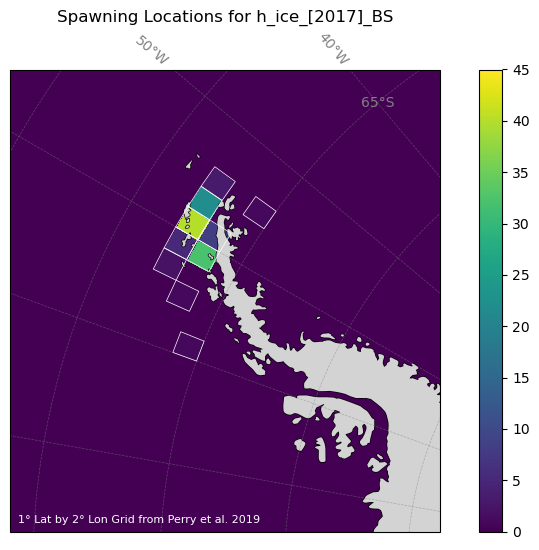

In [49]:
# Step 7: Plot the coarse grid heatmap over the base map
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [-85, -49, -72, -59]  # Adjust extent to -180 to 180 longitude format

# Plot the base map with the region
plot_region(ax, extent)

# Overlay the heatmap using pcolormesh for proper alignment with lat/lon
heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap='viridis',
                                                 transform=ccrs.PlateCarree(),
                                                 vmin=vmin, vmax=vmax,
                                                 add_colorbar=True)

# Outline grid cells where the values are greater than zero
for lat_idx in range(len(lat_bins) - 1):
    for lon_idx in range(len(lon_bins) - 1):
        if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
            # Get the corners of the grid cell
            lon_start = lon_bins[lon_idx]
            lon_end = lon_bins[lon_idx + 1]
            lat_start = lat_bins[lat_idx]
            lat_end = lat_bins[lat_idx + 1]
            
            # Create a rectangle patch for the grid cell
            rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                             linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                             transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
            ax.add_patch(rect)

# Add annotation text
ax.text(0.3, 0.025,  # Coordinates in figure space (x, y)
    "1° Lat by 2° Lon Grid from Perry et al. 2019", 
    transform=ax.transAxes,  # Use axis coordinates for positioning
    ha='center', va='center', fontsize=8, color='white')

plt.title(f'Spawning Locations for {hyp}_{start_years}_{nursery}')
# Save the plot before showing it
plt.savefig(f"{fig_path}/PERRYGRID_spawning_locations_{hyp}_{start_years}_{nursery}.png", dpi=300, bbox_inches='tight')  # Save as a PNG image with 300 DPI

plt.show()

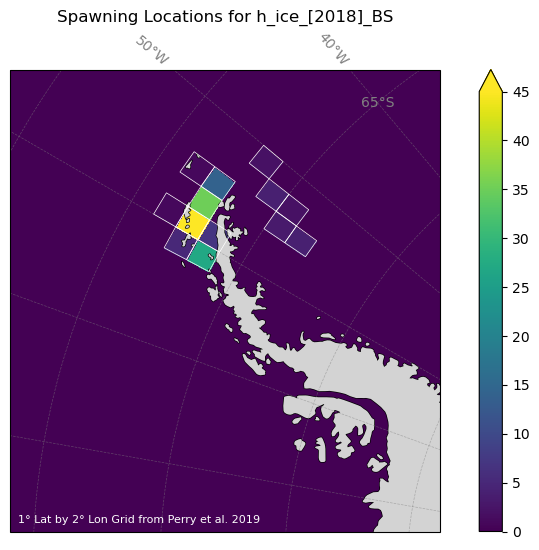

In [50]:
# Define your parameters
start_years = [2018]
hyp = 'h_ice'
nursery = 'BS'

# Pre-process the data
df_filtered = preprocess_data(starting_location_df, start_years, hyp, nursery)

# Step 2: Fix longitudes in the range [0, 360] to [-180, 180]
df_filtered['release_lon'] = df_filtered['release_lon'].apply(lambda lon: lon - 360 if lon > 180 else lon)


# Step 3: Define the coarse grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = 1  # 1 degree latitude resolution
lon_resolution = 2  # 2 degree longitude resolution

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 4: Create a 2D array to hold the counts for each grid cell
coarse_heatmap = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

# Step 5: Bin the data points into the new coarse grid
for _, row in df_filtered.iterrows():
    lat_idx = np.digitize(row['release_lat'], lat_bins) - 1
    lon_idx = np.digitize(row['release_lon'], lon_bins) - 1

    # Ensure the point falls within the grid bounds
    if 0 <= lat_idx < len(lat_bins) - 1 and 0 <= lon_idx < len(lon_bins) - 1:
        coarse_heatmap[lat_idx, lon_idx] += 1  # Increment the count for the grid cell

# Step 6: Convert the coarse heatmap into an xarray DataArray for easy plotting
coarse_heatmap_xr = xr.DataArray(
    coarse_heatmap,
    coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
            ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
    dims=['latitude', 'longitude']
)

# Step 7: Plot the coarse grid heatmap over the base map
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = [-85, -49, -72, -59]  # Adjust extent to -180 to 180 longitude format

# Plot the base map with the region
plot_region(ax, extent)

# Overlay the heatmap using pcolormesh for proper alignment with lat/lon
heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap='viridis',
                                                 transform=ccrs.PlateCarree(),
                                                 vmin=vmin, vmax=vmax,
                                                 add_colorbar=True)

# Outline grid cells where the values are greater than zero
for lat_idx in range(len(lat_bins) - 1):
    for lon_idx in range(len(lon_bins) - 1):
        if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
            # Get the corners of the grid cell
            lon_start = lon_bins[lon_idx]
            lon_end = lon_bins[lon_idx + 1]
            lat_start = lat_bins[lat_idx]
            lat_end = lat_bins[lat_idx + 1]
            
            # Create a rectangle patch for the grid cell
            rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                             linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                             transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
            ax.add_patch(rect)

# Add annotation text
ax.text(0.3, 0.025,  # Coordinates in figure space (x, y)
    "1° Lat by 2° Lon Grid from Perry et al. 2019", 
    transform=ax.transAxes,  # Use axis coordinates for positioning
    ha='center', va='center', fontsize=8, color='white')

plt.title(f'Spawning Locations for {hyp}_{start_years}_{nursery}')
# Save the plot before showing it
plt.savefig(f"{fig_path}/PERRYGRID_spawning_locations_{hyp}_{start_years}_{nursery}.png", dpi=300, bbox_inches='tight')  # Save as a PNG image with 300 DPI

plt.show()